# Cassava Leaf Disease CNN Classification

## Data Preparation

In [1]:
import gc
import json
import math
import multiprocessing
import os
import pickle
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import tqdm
from albumentations.pytorch import ToTensorV2
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch import nn, optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torchvision.models import (
    EfficientNet_B0_Weights,
    EfficientNet_B4_Weights,
    efficientnet_b0,
    efficientnet_b4,
)

%matplotlib inline

In [2]:
print(multiprocessing.cpu_count())

4


In [3]:
DATA_DIR   = Path("/kaggle/input/competitions/cassava-leaf-disease-classification")
train_imgs = DATA_DIR / "train_images"
df = pd.read_csv(DATA_DIR / "train.csv")

df.head(10)

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3
5,1000837476.jpg,3
6,1000910826.jpg,2
7,1001320321.jpg,0
8,1001723730.jpg,4
9,1001742395.jpg,3


In [4]:
with open(os.path.join(DATA_DIR, "label_num_to_disease_map.json")) as f:
    label_map = json.load(f)

# JSON keys come in as strings; convert to int for easy mapping
label_map = {int(k): v for k, v in label_map.items()}
short_name_map = {
    0: "CBB",
    1: "CBSD",
    2: "CGM",
    3: "CMD",
    4: "Healthy"
}

class_names = [
    short_name_map[i] for i in range(len(label_map))
]
label_map

{0: 'Cassava Bacterial Blight (CBB)',
 1: 'Cassava Brown Streak Disease (CBSD)',
 2: 'Cassava Green Mottle (CGM)',
 3: 'Cassava Mosaic Disease (CMD)',
 4: 'Healthy'}

disease
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64


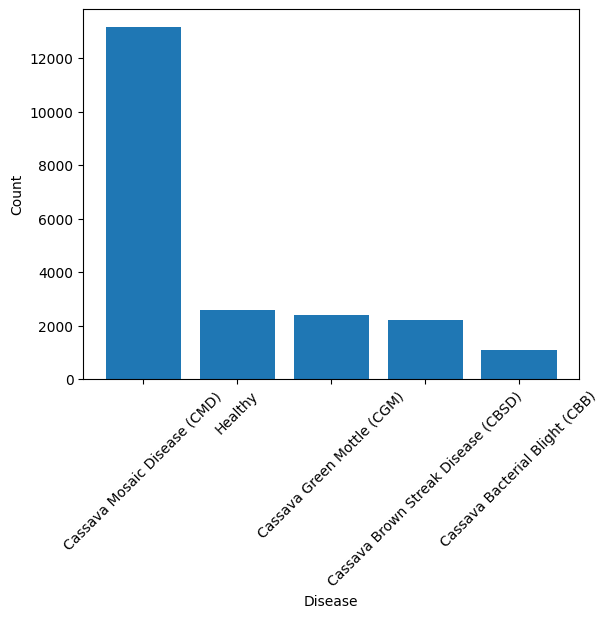

In [5]:
df["disease"] = df["label"].map(label_map)

counts = df["disease"].value_counts()
print(counts)

plt.bar(counts.index, counts.values)
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#fairly significant training imbalance, 
#might be better to train on a more even ds 
#and then fine tune with the remaining CMD examples?
#might make more sense to use CrossEntropyLoss

In [6]:
test_df = pd.read_csv(
    DATA_DIR / "sample_submission.csv"
)

test_df.head()

,image_id,label
0,2216849948.jpg,4


In [7]:
class LeafDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, is_train=False):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.is_train = is_train

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.dataframe.iloc[idx, 0])
        label = self.dataframe.iloc[idx, 1]

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # HWC uint8 numpy

        if self.transform:
            if self.is_train and isinstance(self.transform, CassavaAugmentor):
                # conditional albumentations path — needs label to branch on CBB
                image = self.transform(image, label)

            elif isinstance(self.transform, A.Compose):
                # standard albumentations path (val_pipeline)
                image = self.transform(image=image)["image"]

            elif isinstance(self.transform, T.Compose):
                # torchvision path — convert ndarray to PIL first so
                # ToPILImage() in the transform is effectively a no-op,
                # or remove it from your T.Compose if you want to be clean
                image = self.transform(image)

        if isinstance(image, torch.Tensor) and image.dtype != torch.float32:
            image = image.float() / (255.0 if image.max() > 1.0 else 1.0)

        return image, label

In [8]:
train_df, val_df = train_test_split(
    df, 
    test_size = 0.3, 
    random_state=17,
    stratify=df['label'])

In [9]:
def createDataLoader(df, data_path, transforms, batch_size, num_workers, shuffle, pin_memory=True, is_train=False):
    dataset = LeafDataset(
        df,
        data_path,
        transform=transforms,
        is_train=is_train
    )

    loader = DataLoader(
        dataset,
        batch_size = batch_size,
        shuffle = shuffle,
        num_workers = num_workers,
        persistent_workers = True,
        pin_memory = pin_memory,
        drop_last=True
    )

    return loader

train_path = Path("/kaggle/input/competitions/cassava-leaf-disease-classification/train_images")
test_path = Path("/kaggle/input/competitions/cassava-leaf-disease-classification/test_images")

# Training a Pre-trained CNN

## Base EfficientNet

Originally, the plan was to train on a ResNet50. However, a smaller model which can do this just as efficiently with less overhead will be superior. Diminishing returns are optimized.

In [10]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
])

In [11]:
if __name__ == "__main__":
    train_loader = createDataLoader(
        df=train_df,
        data_path = train_path,
        transforms=train_transform, 
        batch_size=16, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=True,
    )

    test_loader = createDataLoader(
        df=test_df, 
        data_path = test_path,
        transforms=val_transform, 
        batch_size=1, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )

    
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_transform, 
        batch_size=16, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )

In [12]:
class CassavaNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.model = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [13]:
if torch.cuda.is_available():
    print("CUDA device found. Using CUDA.")
    device = torch.device("cuda")
else:
    print("CUDA not available. Using CPU.")
    device = torch.device("cpu")

model = CassavaNet().to(device)

CUDA device found. Using CUDA.
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s] 


In [14]:
summary(model, input_size=(1, 3, 224, 224), depth=4)

Layer (type:depth-idx)                                       Output Shape              Param #
CassavaNet                                                   [1, 5]                    --
├─EfficientNet: 1-1                                          [1, 5]                    --
│    └─Sequential: 2-1                                       [1, 1280, 7, 7]           --
│    │    └─Conv2dNormActivation: 3-1                        [1, 32, 112, 112]         --
│    │    │    └─Conv2d: 4-1                                 [1, 32, 112, 112]         864
│    │    │    └─BatchNorm2d: 4-2                            [1, 32, 112, 112]         64
│    │    │    └─SiLU: 4-3                                   [1, 32, 112, 112]         --
│    │    └─Sequential: 3-2                                  [1, 16, 112, 112]         --
│    │    │    └─MBConv: 4-4                                 [1, 16, 112, 112]         1,448
│    │    └─Sequential: 3-3                                  [1, 24, 56, 56]           --
│

In [15]:
model = model.to(memory_format=torch.channels_last) #improvements in speed
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4,  weight_decay=1e-4)

  4%|▍         | 1/25 [03:11<1:16:40, 191.68s/it]

Epoch 1 		 Training Loss: 0.7156902790992881 		 Validation Loss: 0.5338674895302901
Validation Loss Decreased(inf--->0.533867)


  8%|▊         | 2/25 [05:54<1:06:51, 174.42s/it]

Epoch 2 		 Training Loss: 0.539136821647237 		 Validation Loss: 0.4841263124133196
Validation Loss Decreased(0.533867--->0.484126)


 12%|█▏        | 3/25 [08:37<1:02:02, 169.22s/it]

...

Epoch 13 		 Training Loss: 0.3242024003866399 		 Validation Loss: 0.4436612884110751


 56%|█████▌    | 14/25 [38:29<29:54, 163.18s/it]

Epoch 14 		 Training Loss: 0.3162524321730818 		 Validation Loss: 0.45820518779420405


 56%|█████▌    | 14/25 [41:13<32:23, 176.70s/it]

Epoch 15 		 Training Loss: 0.3052145461616827 		 Validation Loss: 0.4488961188406959
Early stopping at epoch 15


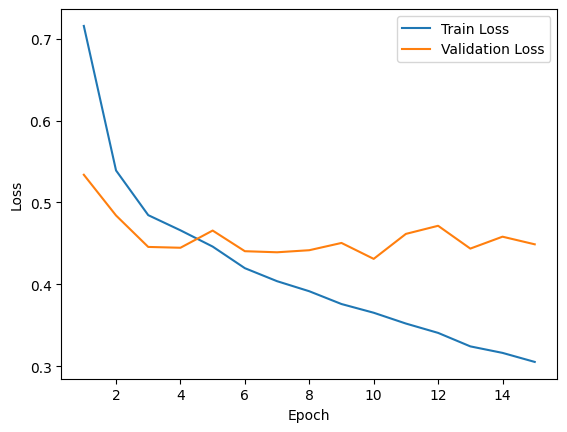

In [16]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=4,
    min_lr=1e-6
)

patience = 5
epochs_no_improve = 0
num_epochs = 25

min_valid_loss = float('inf')
train_losses = []
val_losses = []
epochs = []

plt.figure()

if __name__ == "__main__":
    for epoch in tqdm.tqdm(range(num_epochs)):
        model.train()
        train_loss = 0
        
        for img, label in train_loader:
            img = img.to(device)
            label = label.to(device)
            pred = model(img)
            loss = criterion(pred, label)
    
            #backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * img.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        valid_loss = 0.0
        model.eval()

        with torch.no_grad():
            for img, label in val_loader:
                img = img.to(device)
                label = label.to(device)
                out = model(img)

                loss = criterion(out, label)
                valid_loss += loss.item() * img.size(0)

            valid_loss /= len(val_loader.dataset)
            scheduler.step(valid_loss)
            val_losses.append(valid_loss)
            epochs.append(epoch+1)
    
            print(f'Epoch {epoch+1} \t\t Training Loss: {train_loss} \t\t Validation Loss: {valid_loss}')
    
            if valid_loss < min_valid_loss:
                print(f'Validation Loss Decreased({min_valid_loss:.6f}--->{valid_loss:.6f})')
                min_valid_loss = valid_loss
                torch.save(model.state_dict(), 'Base_EffNet_saved_model.pth')
                epochs_no_improve = 0
                
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
                    
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig("Base_EffNet_Loss_Plots.svg")

del model, optimizer, scheduler
del train_losses, val_losses, epochs

gc.collect()
torch.cuda.empty_cache()

# Pipeline Architecture Optimizations

In [17]:
CBB_CLASS_IDX = 0

# Albumentations library to get more plant-specific transformations, 
# mimicing realistic conditions when taking an image of the leaves
class CassavaAugmentor:
    def __init__(self, crop_size):
        self.crop_size = crop_size
        
        self.geometry = A.Compose([
            A.RandomResizedCrop(size=(crop_size, crop_size), scale=(0.92, 1.0), p=1.0),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.SafeRotate(limit=20, p=0.5),
            A.ElasticTransform(alpha=0.5, sigma=25, p=0.15),
        ])

        self.cbb_only = A.Compose([
            # Amplify water-soaked edge contrast via saturation boost
            A.HueSaturationValue(
                hue_shift_limit=0,
                sat_shift_limit=(-10, 20),  # positive only — never desaturate
                val_shift_limit=0,
                p=0.3
            ),
            # Green channel amplification — CBB necrotic zones go dark,
            # healthy tissue stays bright, mimics chlorophyll loss signal
            A.RGBShift(
                r_shift_limit=0,
                g_shift_limit=8,
                b_shift_limit=0,
                p=0.3
            ),
            # Local contrast — surfaces vein boundaries and angular lesion edges
            A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.4),  # clip_limit up from 2.0
            # Sharpening — accentuates the hard geometric vein boundaries
            A.Sharpen(alpha=(0.2, 0.4), lightness=(0.9, 1.1), p=0.4),
            # Occlusion robustness
            A.CoarseDropout(
                num_holes_range=(1, 3),
                hole_height_range=(4, 8),
                hole_width_range=(4, 8),
                p=0.2
            ),
        ])

        self.non_cbb = A.Compose([
            A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.4
            ),
            A.HueSaturationValue(
                hue_shift_limit=0,
                sat_shift_limit=(-5, 10),  # bidirectional
                val_shift_limit=5,
                p=0.3
            ),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(sigma_limit=(0.1, 0.3), p=0.3),
            A.ISONoise(
                color_shift=(0.01, 0.03),
                intensity=(0.1, 0.3),
                p=0.3
            ),
            A.CoarseDropout(
                num_holes_range=(1, 4),
                hole_height_range=(4, 8),
                hole_width_range=(4, 8),
                p=0.2
            ),

        ])

        self.finalize = A.Compose([
            A.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
            ToTensorV2()
        ])

    def __call__(self, image, label):
        image = self.geometry(image=image)["image"]

        if label == CBB_CLASS_IDX:
            image = self.cbb_only(image=image)["image"]
        else:
            image = self.non_cbb(image=image)["image"]

        image = self.finalize(image=image)["image"]
        return image

In [18]:
val_pipeline = A.Compose([
    A.Resize(224, 224),
    A.Normalize(                        # converts uint8 [0,255] → float32
        mean=[0.485, 0.456, 0.406],     # and applies ImageNet stats
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

In [19]:
if __name__ == "__main__":
    test_loader = createDataLoader(
        df=test_df, 
        data_path = test_path,
        transforms=val_pipeline, 
        batch_size=1, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )

    
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_pipeline, 
        batch_size=64, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )

In [20]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid  = in_channels // reduction
        deep = mid // 2
        
        # use nn.Linear only — no nn.ReLU modules
        self.fc1 = nn.Linear(in_channels, mid)
        self.fc2 = nn.Linear(mid, deep)
        self.fc3 = nn.Linear(deep, in_channels)

    def forward(self, x):
        avg = x.mean(dim=(2, 3))
        mx  = x.amax(dim=(2, 3))

        # F.relu instead of nn.ReLU — invisible to guided backprop hook registration
        def mlp(t):
            return self.fc3(F.relu(self.fc2(F.relu(self.fc1(t)))))

        weight = torch.sigmoid(mlp(avg) + mlp(mx))
        return x * weight.unsqueeze(-1).unsqueeze(-1)

In [21]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.amax(dim=1, keepdim=True)
        weight = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * weight

In [22]:
class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.channel = ChannelAttention(in_channels, reduction)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

In [23]:
class GeM(nn.Module):
    """Generalized Mean Pooling — learns to emphasize discriminative regions
    more than global average pooling which weights everything equally"""
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            1
        ).pow(1.0 / self.p)

In [24]:
class ModifiedCassavaNet(nn.Module):
    def __init__(self, num_classes=5, proj_dim=128):
        super().__init__()
        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # EfficientNetB0 feature blocks:
        # features[0] = stem conv
        # features[1-6] = MBConv blocks  
        # features[7] = head conv
        # Attach aux head at block 5 output — 2/3 depth, 80 channels
        self.early_features = nn.Sequential(*list(self.backbone.features[:6]))
        self.late_features   = nn.Sequential(*list(self.backbone.features[6:]))

        # Aux head at block 5 — 112 channels at this point
        aux_in = 112  # MBConv block 5 output channels for B0
        self.aux_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(aux_in),
            nn.Dropout(0.3),
            nn.Linear(aux_in, num_classes)
        )

        self.dropouts = nn.ModuleList(
            [nn.Dropout(0.2 + 0.05 * i) for i in range(5)]
        )

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Linear(in_features, num_classes)
        )

        # Projection head — only used during training for SupCon
        # maps 1280 → 256 → 128, L2 normalized
        self.projector = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, proj_dim)
        )

        self.cbam = CBAM(in_channels=1280, reduction=16)
        self.gem_pool = GeM()

    def forward(self, x):
        x = self.early_features(x)
        aux_out = self.aux_head(x)      # supervises mid-level features

        x = self.late_features(x)
        x = self.cbam(x)
        x = self.gem_pool(x)
        x = torch.flatten(x, 1)
        features = x

        # BN first, then dropout, then linear
        x_bn = self.head[0](x)
        out = sum(
            self.head[1](drop(x_bn))
            for drop in self.dropouts
        ) / len(self.dropouts)

        proj = F.normalize(self.projector(features), dim=1)

        return out, aux_out, proj

    def extract_features(self, x):
        x = self.early_features(x)
        x = self.late_features(x)
        x = self.cbam(x)
        x = self.gem_pool(x)
        x = torch.flatten(x, 1)
        return x

    def guided_forward(self, x):
        """Forward pass without CBAM for guided backprop compatibility"""
        x = self.early_features(x)
        aux_out = self.aux_head(x)
    
        x = self.late_features(x)
        # skip cbam — its MLP causes shape mismatch in guided backprop backward
        x = self.gem_pool(x)
        x = torch.flatten(x, 1)
    
        x_bn = self.head[0](x)
        out = sum(
            self.head[1](drop(x_bn))
            for drop in self.dropouts
        ) / len(self.dropouts)
    
        return out, aux_out, None

In [25]:
class CassavaNetB4(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # same CBAM and GeM — larger backbone, same attention mechanism
        self.cbam     = CBAM(in_channels=1792, reduction=16)  # B4 outputs 1792 not 1280
        self.gem_pool = GeM()

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.cbam(x)
        x = self.gem_pool(x)
        x = torch.flatten(x, 1)
        x_bn = self.head[0](x)
        return self.head[1](x_bn)   # single output, no aux/proj needed for teacher

In [26]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        N = features.shape[0]

        total = 13158 + 2577 + 2386 + 2189 + 1087
        class_freq = torch.tensor([
            1087/total,   # CBB
            2577/total,   # CBSD  
            2386/total,   # CGM
            13158/total,  # CMD
            2189/total    # Healthy — verify your label ordering matches
        ], device=device)
    
        inv_freq = 1.0 / class_freq
        inv_freq = inv_freq / inv_freq.sum()
    
        sim = (features @ features.T) / self.temperature
    
        logits_mask = torch.eye(N, dtype=torch.bool, device=device)
        sim.masked_fill_(logits_mask, float('-inf'))
    
        labels_1d = labels.view(-1)        # keep 1D for indexing inv_freq later
        labels_col = labels_1d.view(-1, 1) # column for broadcasting comparison
    
        pos_mask = (labels_col == labels_1d) & ~logits_mask
    
        has_positives = pos_mask.sum(dim=1) > 0
        if not has_positives.any():
            return torch.tensor(0.0, device=device, requires_grad=True)
    
        log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)
    
        log_prob_safe = log_prob.clone()
        log_prob_safe[~pos_mask] = 0.0
    
        loss = -(log_prob_safe).sum(dim=1)
        loss = loss[has_positives] / pos_mask[has_positives].sum(dim=1).float()
    
        # apply inverse frequency weighting — CBB anchors count ~13x more than CMD
        anchor_weights = inv_freq[labels_1d[has_positives]]
        loss = loss * anchor_weights
    
        return loss.mean()

In [27]:
#Treating class imbalance (some categories only make up 5% of the ds while CMD makes up 65%)
#Adding label smoothing to prevent overconfidence, better generalization to new images
#Also considering adding cutmix and mixup to improve this generalization but conflicts with class weighted cross entropy
# Maybe use focal loss or soft cross entropy in the future

class_counts = torch.tensor([
    13158,
    2577,
    2386,
    2189,
    1087
])

device = "cuda"

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label']),
    y=df['label']
)

CBB_IDX = 0
class_weights[CBB_IDX] *= 0.8

## Parent Model Training

In [28]:
if __name__ == "__main__":
    augmentor = CassavaAugmentor(crop_size=380)
    train_loader = createDataLoader(
        df=train_df,
        data_path = train_path,
        transforms=augmentor, 
        batch_size=32, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=True,
        is_train=True
    )

In [29]:
class_weights = torch.FloatTensor(class_weights).to(device)
teacher = CassavaNetB4().to(device)
teacher = teacher.to(memory_format=torch.channels_last)
scaler  = GradScaler(device)

criterion  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer  = optim.Adam(teacher.parameters(), lr=2e-4, weight_decay=1e-4)

num_epochs        = 25
accumulation_steps = 4
min_valid_loss    = float("inf")
best_macro_f1     = -float("inf")

steps_per_epoch = math.ceil(len(train_loader) / accumulation_steps)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=2e-4,              # higher than student — B4 benefits from more aggressive LR
    epochs=num_epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)


if __name__ == "__main__":
    for epoch in tqdm.tqdm(range(num_epochs)):
        # ── Train ──
        teacher.train()
        train_loss = 0.0
        optimizer.zero_grad()

        for i, (img, label) in enumerate(train_loader):
            img   = img.to(device, memory_format=torch.channels_last)
            label = label.to(device)

            with autocast(device):
                out  = teacher(img)           # single output — no aux, no proj
                loss = criterion(out, label)  # CE only — no SupCon needed
                loss = loss / accumulation_steps

            scaler.scale(loss).backward()

            is_update_step = (
                (i + 1) % accumulation_steps == 0
                or (i + 1) == len(train_loader)
            )

            if is_update_step:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                # OneCycleLR advances once per optimizer update
                scheduler.step()

            # Undo the division when reporting loss
            train_loss += loss.item() * accumulation_steps * img.size(0)

        train_loss /= len(train_loader.dataset)

        # ── Val — keep for checkpoint selection only ──
        teacher.eval()
        all_labels = []
        all_preds = []
        valid_loss = 0.0
        with torch.no_grad():
            for img, label in val_loader:
                img   = img.to(device)
                label = label.to(device)
                out   = teacher(img)
                loss  = criterion(out, label)
                valid_loss += loss.item() * img.size(0)
                preds = out.argmax(dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(label.cpu().numpy())

        valid_loss /= len(val_loader.dataset)

        val_macro_f1 = f1_score(
            all_labels,
            all_preds,
            average="macro"
        )

        print(f'Epoch {epoch+1} \t\t Training Loss: {train_loss} \t\t Validation Loss: {valid_loss}')

        # save best — want best generalizing teacher, not last
        if val_macro_f1 > best_macro_f1:
            print(f'Macro F1 Increased({best_macro_f1:.6f}--->{val_macro_f1:.6f})')
            best_macro_f1 = val_macro_f1
            torch.save(teacher.state_dict(), "Teacher_B4_saved_model.pth")
            

del teacher, optimizer, scheduler, scaler, augmentor, train_loader

gc.collect()
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 154MB/s]
  4%|▍         | 1/25 [04:54<1:57:59, 294.99s/it]

Epoch 1 		 Training Loss: 1.5804162652977893 		 Validation Loss: 1.6677703584094656
Macro F1 Increased(-inf--->0.254555)
Epoch 2 		 Training Loss: 1.3176359804607707 		 Validation Loss: 1.5408802935638903
Macro F1 Increased(0.254555--->0.333805)


 12%|█▏        | 3/25 [13:57<1:41:30, 276.86s/it]

Epoch 3 		 Training Loss: 1.073276921697824 		 Validation Loss: 1.5031867945305655
Macro F1 Increased(0.333805--->0.370943)


...

Epoch 23 		 Training Loss: 0.5790762499192691 		 Validation Loss: 1.480117196531682


 96%|█████████▌| 24/25 [1:49:15<04:32, 272.63s/it]

Epoch 24 		 Training Loss: 0.5855085915825734 		 Validation Loss: 1.458599472640088


100%|██████████| 25/25 [1:53:49<00:00, 273.18s/it]

Epoch 25 		 Training Loss: 0.5796373784004818 		 Validation Loss: 1.4635188123518803


## Modified Model training

In [30]:
if __name__ == "__main__":
    augmentor = CassavaAugmentor(crop_size=224)
    train_loader = createDataLoader(
        df=train_df,
        data_path = train_path,
        transforms=augmentor, 
        batch_size=64, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=True,
        is_train=True
    )

In [31]:
model = ModifiedCassavaNet().to(device)
model = model.to(memory_format=torch.channels_last) #improvements in speed
if torch.amp.autocast_mode.is_autocast_available(device): #dtype speed optimization to make most of GPU
    scaler = GradScaler(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

  0%|          | 0/75 [00:00<?, ?it/s]/tmp/ipykernel_24/3837306698.py:80: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
  1%|▏         | 1/75 [02:39<3:16:52, 159.63s/it]

Epoch 1 		 Training Loss: 2.3182715287138196 		 Validation Loss: 1.69925792967419
Macro F1 Increased(-inf--->0.235093)
Validation Loss Decreased(inf--->1.699258)


  3%|▎         | 2/75 [04:51<2:54:09, 143.15s/it]

Epoch 2 		 Training Loss: 2.1431922792886917 		 Validation Loss: 1.5959933058123723
Macro F1 Increased(0.235093--->0.292640)
Validation Loss Decreased(1.699258--->1.595993)


  4%|▍         | 3/75 [07:03<2:45:45, 138.13s/it]

...

Epoch 63 		 Training Loss: 0.9654171371791076 		 Validation Loss: 1.0258085714322385


 85%|████████▌ | 64/75 [2:18:28<23:48, 129.84s/it]

Epoch 64 		 Training Loss: 0.963314290214478 		 Validation Loss: 1.0146011899193499


 85%|████████▌ | 64/75 [2:20:35<24:09, 131.80s/it]

Epoch 65 		 Training Loss: 0.9571596861219919 		 Validation Loss: 1.0106584281564872
Early stopping


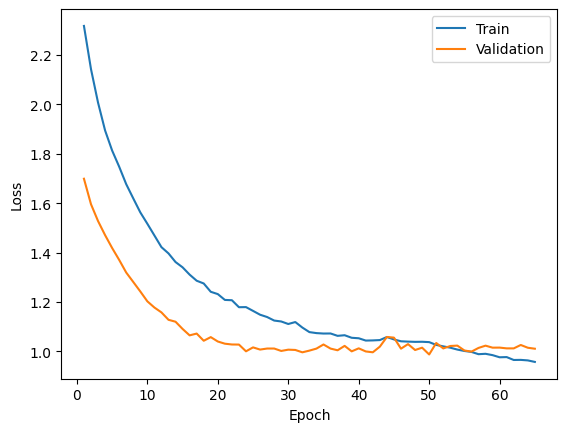

In [32]:
num_epochs = 75

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)

accumulation_steps = 4
patience = 15
epochs_no_improve = 0

min_valid_loss = float("inf")
best_macro_f1 = -float("inf")

train_losses = []
val_losses = []
epochs = []

teacher = CassavaNetB4().to(device)
teacher.load_state_dict(torch.load("Teacher_B4_saved_model.pth"))
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

temp = 4.0

if __name__ == "__main__":
    T_0 = 25
    supcon_loss_fn = SupConLoss(temperature=0.07)
    supcon_lambda  = 0.1
    
    for epoch in tqdm.tqdm(range(num_epochs)):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

    
        for i, (img, label) in enumerate(train_loader):
            img   = img.to(device, memory_format=torch.channels_last)
            label = label.to(device)
    
            with autocast(device):
                with torch.no_grad():
                    teacher_out = teacher(img)
                    
                out, aux_out, proj = model(img)
    
                main_loss = criterion(out, label)
                aux_loss  = criterion(aux_out, label)
                con_loss  = supcon_loss_fn(proj, label)
    
                # weights reset each cycle — ramp in after LR has peaked
                aux_weight = min(0.3, 0.1 * (epoch - 3) / 15) if epoch >= 3 else 0.0
                sc_weight = min(supcon_lambda, supcon_lambda * (epoch - 5) / 20) if epoch >= 5 else 0.0
    
                distill_loss = nn.KLDivLoss(reduction='batchmean')(
                    F.log_softmax(out / temp, dim=1),
                    F.softmax(teacher_out / temp, dim=1)
                ) * (temp ** 2)
        
                loss = (
                    main_loss
                    + aux_weight * aux_loss
                    + sc_weight  * con_loss
                    + 0.3        * distill_loss
                )
    
            scaler.scale(loss).backward()
    
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()

            train_loss += loss.item() * img.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # ---------------- Validation ----------------
        model.eval()
        all_labels = []
        all_preds = []
        valid_loss = 0.0

        with torch.no_grad():
            for img, label in val_loader:
                img = img.to(device)
                label = label.to(device)
                out, aux_out, proj = model(img)
                loss = criterion(out, label)
                valid_loss += loss.item() * img.size(0)
                preds = out.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(label.cpu().numpy())


        valid_loss /= len(val_loader.dataset)
        val_losses.append(valid_loss)
        epochs.append(epoch + 1)

        val_macro_f1 = f1_score(
            all_labels,
            all_preds,
            average="macro"
        )

        print(f'Epoch {epoch+1} \t\t Training Loss: {train_loss} \t\t Validation Loss: {valid_loss}')

        # ---------------- Checkpoint ----------------
        if val_macro_f1 > best_macro_f1:
            print(f'Macro F1 Increased({best_macro_f1:.6f}--->{val_macro_f1:.6f})')
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), "Modified_EffNet_f1_saved_model.pth")
            epochs_no_improve = 0
            
        if valid_loss < min_valid_loss:
            print(f'Validation Loss Decreased({min_valid_loss:.6f}--->{valid_loss:.6f})')
            min_valid_loss = valid_loss
            torch.save(
                model.state_dict(),
                "Modified_EffNet_val_loss_saved_model.pth"
            )
            epochs_no_improve = 0

        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping")
                break

plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "Modified_EffNet_Loss_Plots.svg",
    bbox_inches="tight"
)

del model, teacher, optimizer, scheduler
del train_losses, val_losses, epochs
del augmentor, train_loader

gc.collect()
torch.cuda.empty_cache()

# Evaluation

In [33]:
from sklearn.utils import resample

CLASS_NAMES = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]

def subsample_for_viz(features, labels, n=2000, random_state=42):
    """Stratified subsample — preserves class proportions"""
    idx = []
    classes = np.unique(labels)
    n_per_class = n // len(classes)
    
    for c in classes:
        class_idx = np.where(labels == c)[0]
        # if class has fewer samples than quota, take all of them
        n_take = min(n_per_class, len(class_idx))
        sampled = resample(class_idx, n_samples=n_take, 
                          random_state=random_state, replace=False)
        idx.extend(sampled)
    
    idx = np.array(idx)
    return features[idx], labels[idx]

In [34]:
def plot_pca(all_features, all_labels, save_prefix=None):
    pca_2d = PCA(n_components=2, random_state=42).fit_transform(all_features)
    fig, ax = plt.subplots(figsize=(9, 7))
    for i, name in enumerate(CLASS_NAMES):
        mask = all_labels == i
        ax.scatter(pca_2d[mask, 0], pca_2d[mask, 1], label=name, alpha=0.6, s=8)
    ax.legend()
    ax.set_title(f"PCA Feature Embedding — {save_prefix or 'model'}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"feature_pca_{save_prefix}.svg")
    plt.show()

In [35]:
def plot_tsne(features_pca, all_labels, save_prefix=None):
    feat_sample, label_sample = subsample_for_viz(features_pca, all_labels, n=len(all_labels))
    embedding = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(feat_sample)

    fig, ax = plt.subplots(figsize=(10, 8))   # ← was missing in your version
    for i, name in enumerate(CLASS_NAMES):
        mask = label_sample == i
        ax.scatter(embedding[mask, 0], embedding[mask, 1], label=name, alpha=0.65, s=8)
    ax.legend()
    ax.set_title(f"t-SNE Feature Embedding — {save_prefix or 'model'}")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"feature_tsne_{save_prefix}.svg")
    plt.show()

In [36]:
from sklearn.metrics import classification_report

CLASS_NAMES = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]


# ─────────────────────────────────────────────
# Unified evaluation function
# Works with CassavaNet (single output) and
# ModifiedCassavaNet (out, aux_out tuple)
# ─────────────────────────────────────────────
def evaluate(
    model,
    loader,
    criterion,
    device,
    save_prefix=None,
    run_tsne=True,
    run_pca=False,
):
    model.eval()

    all_features = []
    all_logits   = []
    all_probs    = []
    all_preds    = []
    all_labels   = []
    valid_loss   = 0.0

    is_modified = isinstance(model, ModifiedCassavaNet)

    if not is_modified:
        _feat_buffer = []
        def _feat_hook(module, input, output):
            _feat_buffer.append(output.flatten(1).cpu())
        if hasattr(model, 'model'):
            hook = model.model.avgpool.register_forward_hook(_feat_hook)
        else:
            hook = model.avgpool.register_forward_hook(_feat_hook)

    with torch.no_grad():
        for img, label in loader:
            img = img.to(device)
            label = label.to(device)

            if is_modified:
                out, aux_out, proj = model(img) # single forward pass — no extract_features
                features = model.extract_features(img)
            else:
                out = model(img)
                features = _feat_buffer.pop()

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(out, dim=1)

            loss = criterion(out, label)
            valid_loss += loss.item() * img.size(0)

            all_features.append(features.cpu())
            all_logits.extend(out.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    if not is_modified:
        hook.remove()

    valid_loss /= len(loader.dataset)

    all_features = torch.cat(all_features).numpy()
    all_preds    = np.array(all_preds)
    all_labels   = np.array(all_labels)
    all_probs    = np.array(all_probs)
    all_logits   = np.array(all_logits)

    # ── metrics ──
    print(f"\nValidation loss: {valid_loss:.4f}\n")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    # ── confusion matrix ──
    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax)
    plt.title(f"Confusion Matrix — {save_prefix or 'model'}")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"confusion_matrix_{save_prefix}.svg")
    plt.show()

    # ── PCA reduction (always computed — needed for t-SNE input) ──
    print("Logging: Starting diagnostic checks...")
    all_features = np.asarray(all_features, dtype=np.float32)
    print(f"Features shape: {all_features.shape}, dtype: {all_features.dtype}")

    print("Logging: Launching PCA...")
    features_pca = PCA(n_components=50, svd_solver='full', random_state=42).fit_transform(all_features)
    print("Logging: Finished PCA Reduction")

    if run_pca:
        plot_pca(all_features, all_labels, save_prefix)

    if run_tsne:
        plot_tsne(features_pca, all_labels, save_prefix)

    # ── saves ──
    if save_prefix:
        for name, obj in [
            ("features", all_features),
            ("labels",   all_labels),
            ("preds",    all_preds),
            ("probs",    all_probs),
            ("logits",   all_logits),
        ]:
            with open(f"eval_{name}_{save_prefix}.pkl", "wb") as f:
                pickle.dump(obj, f)
        print(f"Saved eval artifacts with prefix '{save_prefix}'")

    return {
        "loss":     valid_loss,
        "preds":    all_preds,
        "labels":   all_labels,
        "probs":    all_probs,
        "logits":   all_logits,
        "features": all_features,
    }

## Base Model

In [37]:
from collections import OrderedDict

num_classes = 5
device = "cuda"

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)


# 3. Load checkpoint
checkpoint = torch.load(
    "Base_EffNet_saved_model.pth",
    map_location=device
)

# Remove "model." prefix
new_state_dict = OrderedDict()

for k, v in checkpoint.items():
    new_state_dict[k.replace("model.", "")] = v

model.load_state_dict(new_state_dict)

# 4. Move to GPU and evaluation mode
model = model.to(device)
model.eval()

correct = 0
total = 0


Validation loss: 1.2842

              precision    recall  f1-score   support

         CBB       0.52      0.67      0.59       326
        CBSD       0.80      0.78      0.79       656
         CGM       0.76      0.72      0.74       713
         CMD       0.94      0.95      0.95      3934
     Healthy       0.69      0.64      0.66       771

    accuracy                           0.85      6400
   macro avg       0.74      0.75      0.75      6400
weighted avg       0.86      0.85      0.85      6400



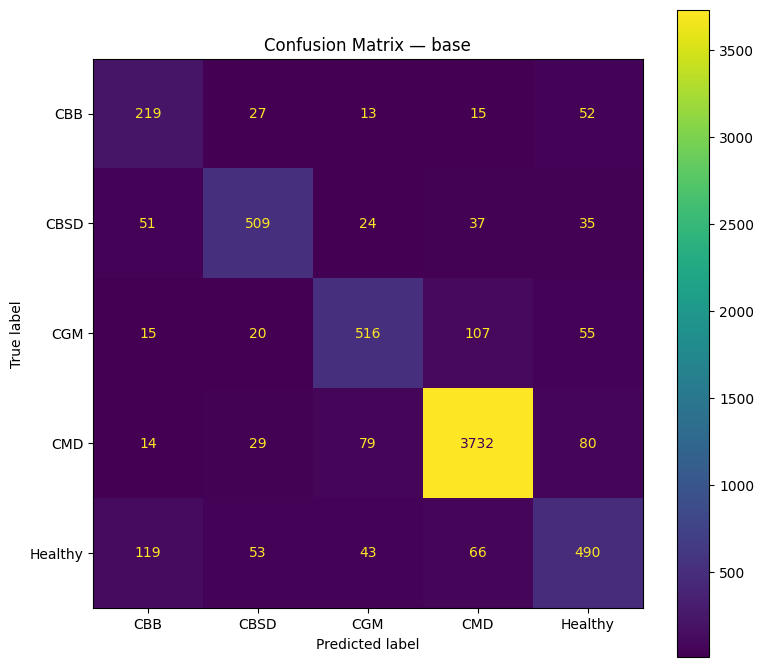

Logging: Starting diagnostic checks...
Features shape: (6400, 1280), dtype: float32
Logging: Launching PCA...
Logging: Finished PCA Reduction


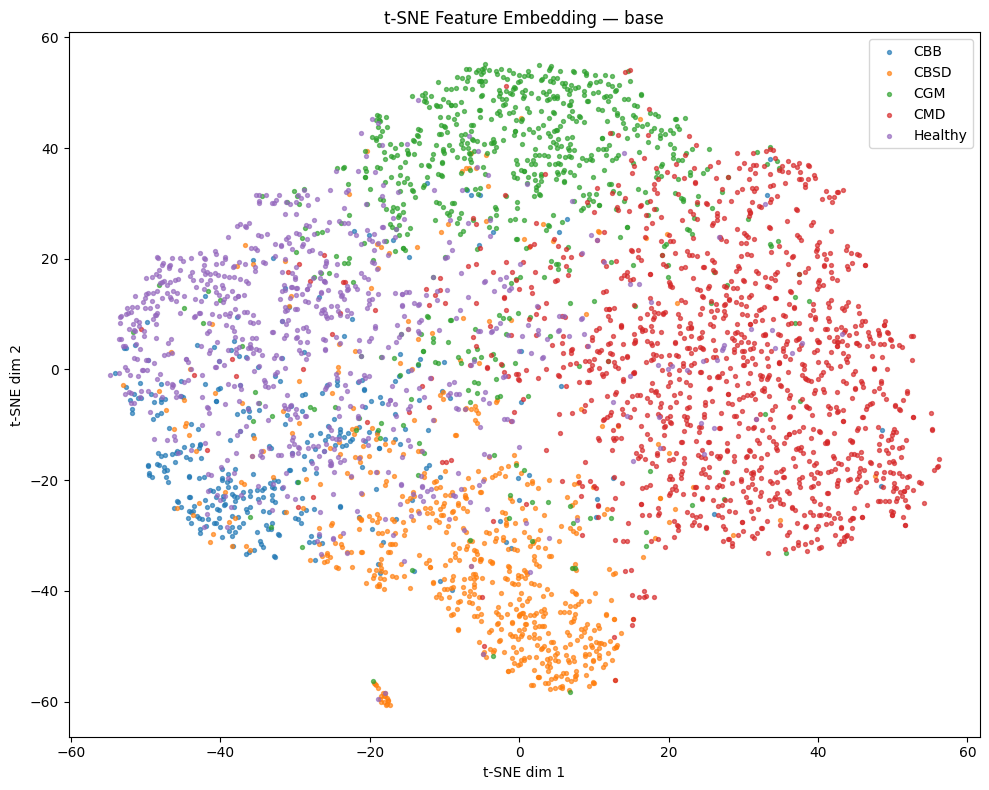

Saved eval artifacts with prefix 'base'


In [38]:
if __name__ == "__main__":    
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_transform, 
        batch_size=64, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )

    base_results = evaluate(
        model, val_loader, criterion, device,
        save_prefix="base"
    )

    del val_loader
    gc.collect()
    torch.cuda.empty_cache()

In [39]:
if __name__ == "__main__":
    test_loader = createDataLoader(
        df=test_df, 
        data_path = test_path,
        transforms=val_transform, 
        batch_size=1, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )

    with torch.no_grad():
        for img, label in test_loader:
            img = img.to(device)
            label = label.to(device)
            output = model(img)
            
            preds = torch.argmax(output, 1) 
            
            correct += (preds == label).sum().item()
            total += label.size(0)
    
    del test_loader, model
    gc.collect()
    torch.cuda.empty_cache()
accuracy = correct / total
print(f"Test accuracy percentage: {accuracy * 100:.2f}%")

Test accuracy percentage: 0.00%


## Modified Model

In [40]:
class TTADataset(Dataset):
    def __init__(self, dataframe, img_dir, n_aug=5):
        self.dataframe = dataframe
        self.img_dir   = img_dir
        self.n_aug     = n_aug

        self.base = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
        self.tta = A.Compose([
            A.RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0)),
            A.HorizontalFlip(p=0.5),
            A.SafeRotate(limit=10, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.dataframe.iloc[idx, 0])
        label    = self.dataframe.iloc[idx, 1]

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # base + n augmented versions stacked together
        views = [self.base(image=image)["image"]]
        for _ in range(self.n_aug):
            views.append(self.tta(image=image)["image"])

        return torch.stack(views), label  # (n_aug+1, C, H, W)

In [41]:
def evaluate_tta(model, dataframe, img_dir, device, n_aug=5):
    dataset = TTADataset(dataframe, img_dir, n_aug=n_aug)
    loader  = DataLoader(dataset, batch_size=16, shuffle=False,
                         num_workers=4, pin_memory=True)

    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for views, label in loader:
            # views: (B, n_aug+1, C, H, W)
            B, N, C, H, W = views.shape
            views = views.view(B * N, C, H, W).to(device)

            out, _, _ = model(views)
            probs = torch.softmax(out, dim=1)

            # reshape back to (B, N, num_classes) and average over augmentations
            probs = probs.view(B, N, -1).mean(dim=1)  # (B, num_classes)

            all_preds.append(probs.cpu())
            all_labels.extend(label.numpy())

    all_preds   = torch.cat(all_preds).numpy()
    all_labels  = np.array(all_labels)
    final_preds = all_preds.argmax(axis=1)

    print(classification_report(all_labels, final_preds, target_names=CLASS_NAMES))

    cm   = confusion_matrix(all_labels, final_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax)
    plt.title("Confusion Matrix — TTA")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

### Val Loss Stopping

In [42]:
model = ModifiedCassavaNet(num_classes=5)
device = "cuda"

checkpoint = torch.load(
    "Modified_EffNet_val_loss_saved_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

# 4. Move to GPU and evaluation mode
model = model.to(device)
model.eval()

correct = 0
total = 0

              precision    recall  f1-score   support

         CBB       0.48      0.69      0.57       326
        CBSD       0.72      0.78      0.75       657
         CGM       0.76      0.71      0.73       716
         CMD       0.96      0.92      0.94      3948
     Healthy       0.66      0.65      0.65       773

    accuracy                           0.84      6420
   macro avg       0.71      0.75      0.73      6420
weighted avg       0.85      0.84      0.84      6420



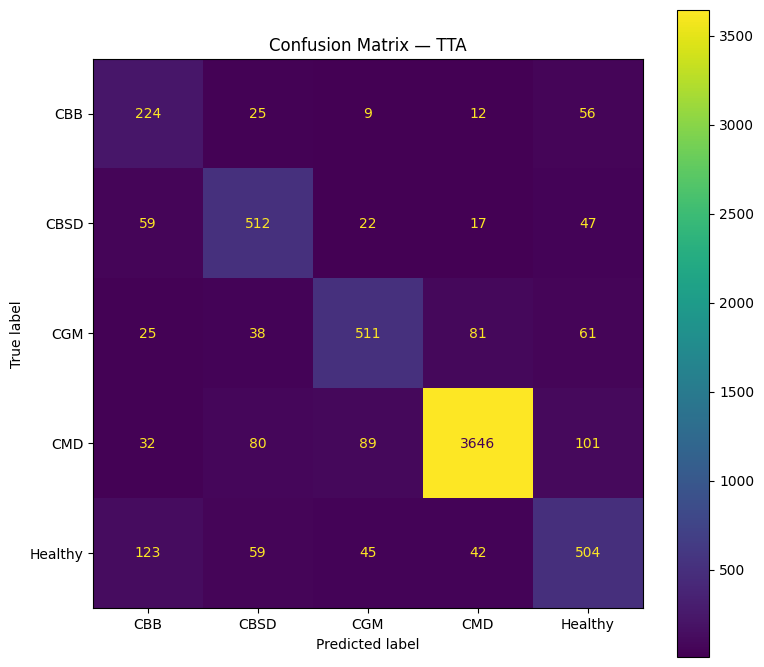

In [43]:
if __name__ == "__main__":
    tta_preds, tta_labels = evaluate_tta(
        model, val_df, train_path, device, n_aug=5
    )


Validation loss: 0.9873

              precision    recall  f1-score   support

         CBB       0.47      0.65      0.55       326
        CBSD       0.70      0.77      0.73       656
         CGM       0.76      0.73      0.74       713
         CMD       0.96      0.92      0.94      3934
     Healthy       0.64      0.64      0.64       771

    accuracy                           0.84      6400
   macro avg       0.71      0.74      0.72      6400
weighted avg       0.85      0.84      0.84      6400



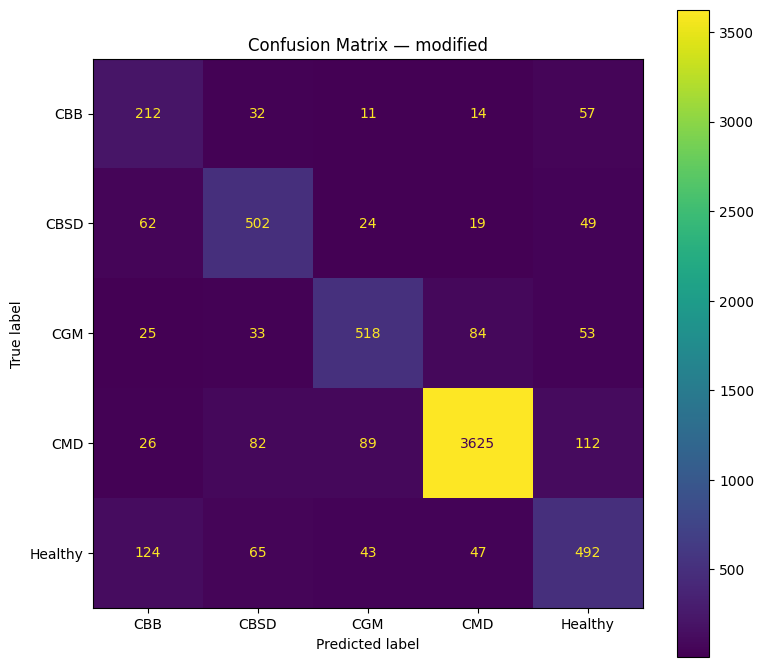

Logging: Starting diagnostic checks...
Features shape: (6400, 1280), dtype: float32
Logging: Launching PCA...
Logging: Finished PCA Reduction


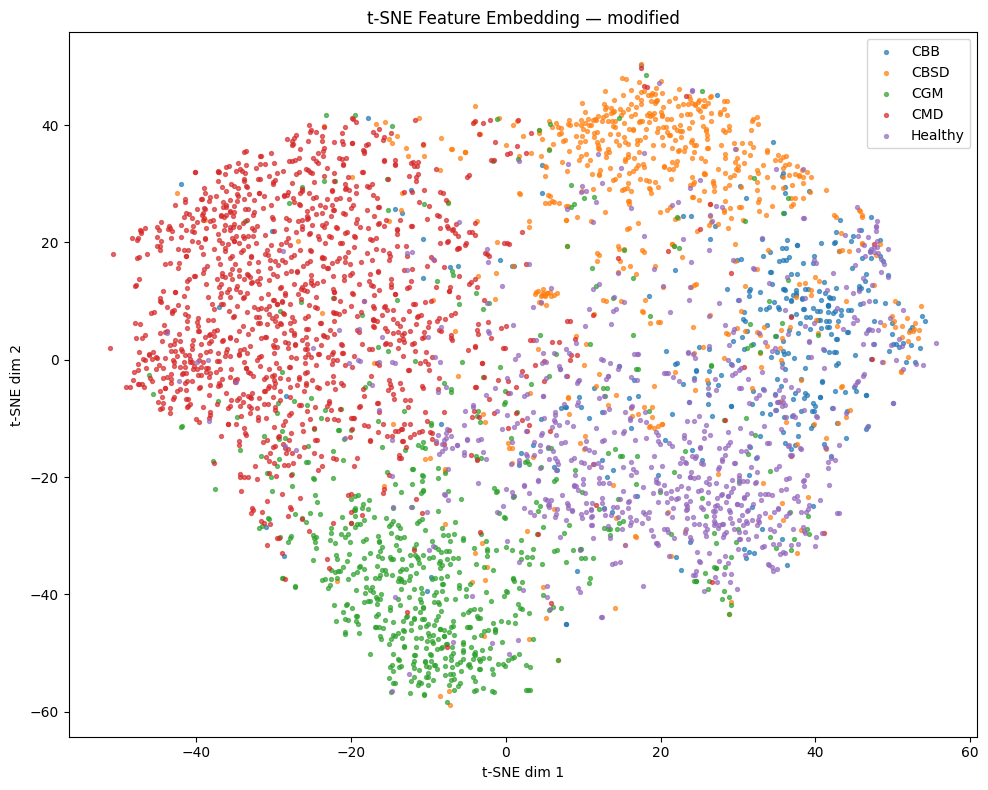

Saved eval artifacts with prefix 'modified'


In [44]:
if __name__ == "__main__":
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_pipeline, 
        batch_size=64, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )
    
    mod_results = evaluate(
        model, val_loader, criterion, device,
        save_prefix="modified"
    )

    del val_loader
    gc.collect()
    torch.cuda.empty_cache()

In [45]:
if __name__ == "__main__":
    test_loader = createDataLoader(
        df=test_df, 
        data_path = test_path,
        transforms=val_pipeline, 
        batch_size=1, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )
    
    with torch.no_grad():
        for img, label in test_loader:
            img = img.to(device)
            label = label.to(device)
            output, _, proj = model(img)
            
            preds = torch.argmax(output, 1) 
            
            correct += (preds == label).sum().item()
            total += label.size(0)
    
    del test_loader, model
    gc.collect()
    torch.cuda.empty_cache()
accuracy = (correct / total) if total > 0 else 0.0
print(f"Test accuracy percentage: {accuracy * 100:.2f}%")

Test accuracy percentage: 0.00%


### F1 Stopping

In [46]:
model = ModifiedCassavaNet(num_classes=5)
device = "cuda"

checkpoint = torch.load(
    "Modified_EffNet_val_loss_saved_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

# 4. Move to GPU and evaluation mode
model = model.to(device)
model.eval()

correct = 0
total = 0

              precision    recall  f1-score   support

         CBB       0.49      0.69      0.57       326
        CBSD       0.71      0.77      0.74       657
         CGM       0.75      0.72      0.74       716
         CMD       0.96      0.92      0.94      3948
     Healthy       0.67      0.66      0.66       773

    accuracy                           0.84      6420
   macro avg       0.72      0.75      0.73      6420
weighted avg       0.85      0.84      0.85      6420



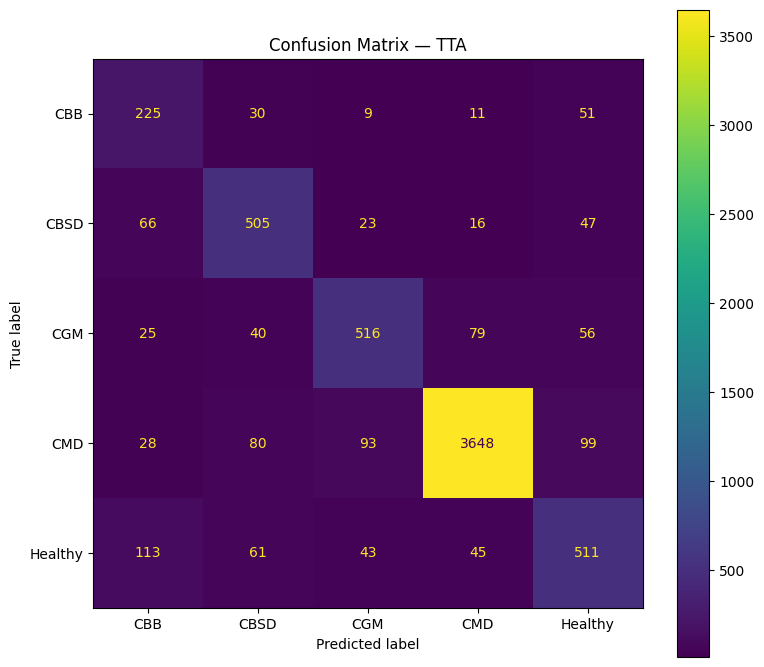

In [47]:
if __name__ == "__main__":
    tta_preds, tta_labels = evaluate_tta(
        model, val_df, train_path, device, n_aug=5
    )


Validation loss: 0.9873

              precision    recall  f1-score   support

         CBB       0.47      0.65      0.55       326
        CBSD       0.70      0.77      0.73       656
         CGM       0.76      0.73      0.74       713
         CMD       0.96      0.92      0.94      3934
     Healthy       0.64      0.64      0.64       771

    accuracy                           0.84      6400
   macro avg       0.71      0.74      0.72      6400
weighted avg       0.85      0.84      0.84      6400



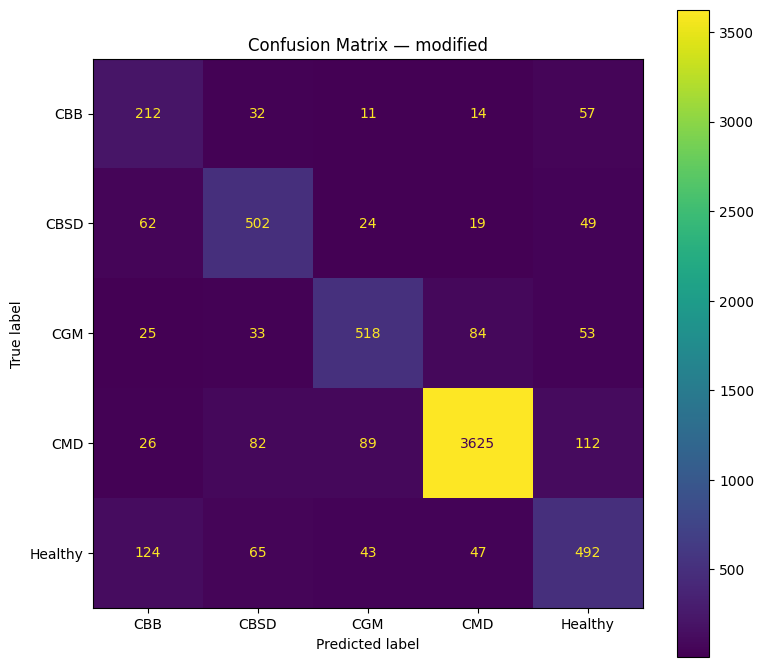

Logging: Starting diagnostic checks...
Features shape: (6400, 1280), dtype: float32
Logging: Launching PCA...
Logging: Finished PCA Reduction


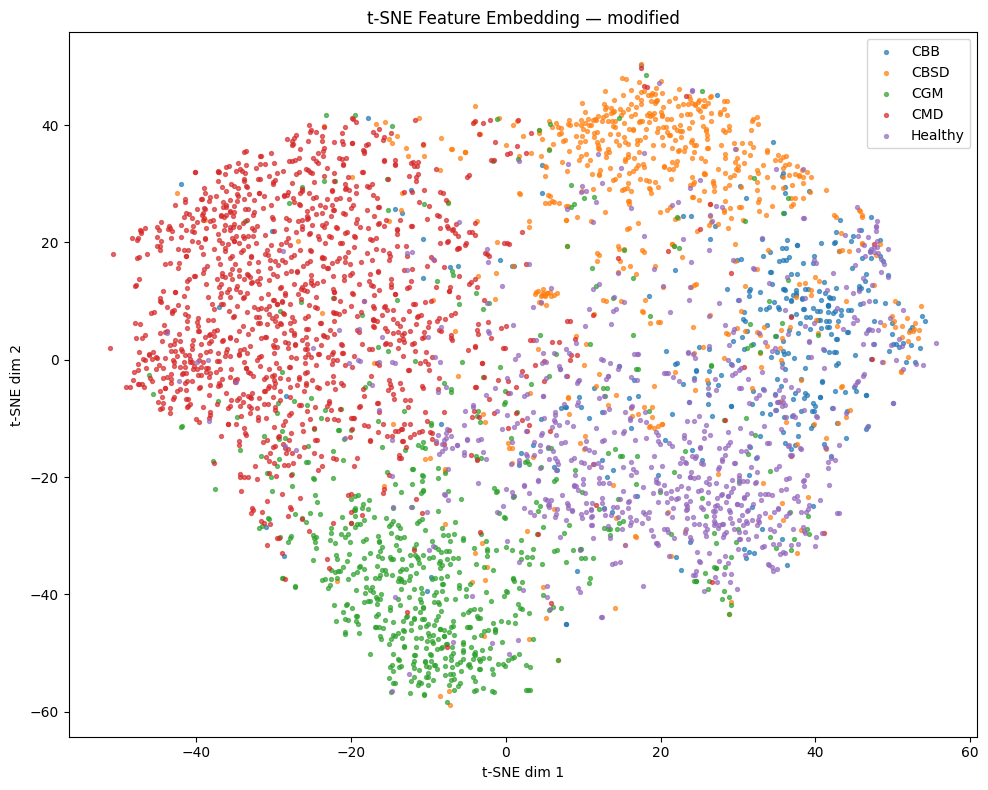

Saved eval artifacts with prefix 'modified'


In [48]:
if __name__ == "__main__":
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_pipeline, 
        batch_size=64, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )
    
    mod_results = evaluate(
        model, val_loader, criterion, device,
        save_prefix="modified"
    )

    del val_loader
    gc.collect()
    torch.cuda.empty_cache()

In [49]:
if __name__ == "__main__":    
    test_loader = createDataLoader(
        df=test_df, 
        data_path = test_path,
        transforms=val_pipeline, 
        batch_size=1, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )
    
    with torch.no_grad():
        for img, label in test_loader:
            img = img.to(device)
            label = label.to(device)
            output, _, proj = model(img)
            
            preds = torch.argmax(output, 1) 
            
            correct += (preds == label).sum().item()
            total += label.size(0)
    
    del test_loader, model
    gc.collect()
    torch.cuda.empty_cache()
accuracy = (correct / total) if total > 0 else 0.0
print(f"Test accuracy percentage: {accuracy * 100:.2f}%")

Test accuracy percentage: 0.00%


# Implementing Guided Grad-CAM

## Grad-CAM

In [50]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
            
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if isinstance(output, tuple):
            output = output[0]

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
    
        self.model.zero_grad()
        output[:, class_idx].backward()
    
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
    
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
    
        cam -= cam.min()
        cam /= cam.max() + 1e-8
    
        return cam

In [51]:
def show_cam_on_image(img, cam):
    cam = cam.squeeze().cpu().numpy()
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = heatmap * 0.4 + img * 255

    plt.imshow(overlay.astype(np.uint8))
    plt.axis("off")

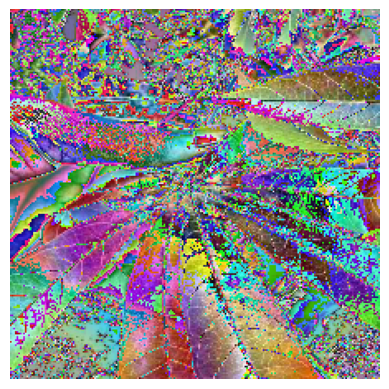

In [52]:
model = ModifiedCassavaNet(num_classes=5)

checkpoint = torch.load(
    "Modified_EffNet_f1_saved_model.pth",
    map_location="cpu"
)

model.load_state_dict(checkpoint)

target_layer = model.backbone.features[8]

model.eval()
gradcam = GradCAM(model, target_layer)

if __name__ == "__main__":
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_pipeline, 
        batch_size=64, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )
    
    img, label = next(iter(val_loader))
    img = img.to("cpu")
    
    cam = gradcam.generate(img[:1])
    
    show_cam_on_image(
        img[0].permute(1,2,0).cpu().numpy(),
        cam
    )

## Guided-Backpropogation

In [53]:
class Guided_backprop:
    def __init__(self, model):
        self.model = model
        self.image_reconstruction = None # store R0
        self.activation_maps = []  # store f1, f2, ... 
        self.model.eval()
        self.register_hooks()

    def register_hooks(self):
        def first_layer_hook_fn(module, grad_in, grad_out):
            self.image_reconstruction = grad_in[0] 

        def forward_hook_fn(module, input, output):
            self.activation_maps.append(output)

        def backward_hook_fn(module, grad_in, grad_out):
            grad = self.activation_maps.pop() 
            # for the forward pass, after the ReLU operation, 
            # if the output value is positive, we set the value to 1,
            # and if the output value is negative, we set it to 0.
            grad[grad > 0] = 1 
            
            # grad_out[0] stores the gradients for each feature map,
            # and we only retain the positive gradients
            positive_grad_out = torch.clamp(grad_out[0], min=0.0)
            new_grad_in = positive_grad_out * grad

            return (new_grad_in,)

        modules = dict(model.named_modules())

        # travese the modules，register forward hook & backward hook
        # for the ReLU
        for name, module in modules.items():
            if isinstance(module, nn.ReLU):
                module.register_forward_hook(forward_hook_fn)
                module.register_backward_hook(backward_hook_fn)

        # register backward hook for the first conv layer
        for name, module in modules.items():
            if isinstance(module, nn.Conv2d):
                module.register_full_backward_hook(first_layer_hook_fn)
                break
        
    def visualize(self, input_image, target_class, device):
        input_image = input_image.to(device)
        input_image = input_image.contiguous(memory_format=torch.contiguous_format)
        input_image.requires_grad_(True)
        
        model_output = self.model(input_image)

        if isinstance(model_output, tuple):
            model_output = model_output[0]
        
        self.model.zero_grad()
        pred_class = model_output.argmax().item()
        
        grad_target_map = torch.zeros(model_output.shape,
                                      dtype=torch.float,
                                      device=device)
        if target_class is not None:
            grad_target_map[0][target_class] = 1
        else:
            grad_target_map[0][pred_class] = 1
        
        model_output.backward(grad_target_map)
        
        result = self.image_reconstruction.data[0].permute(1,2,0)
        return result.numpy()

In [54]:
def normalize(image):
    norm = (image - image.mean())/image.std()
    norm = norm * 0.1
    norm = norm + 0.5
    norm = norm.clip(0, 1)
    return norm

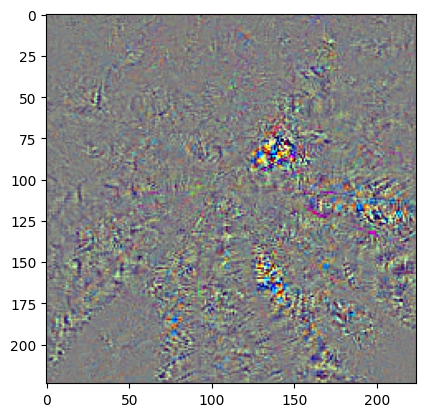

In [55]:

device = torch.device("cpu")
model = model.to(device).eval()

if __name__ == "__main__":
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_pipeline, 
        batch_size=64, 
        num_workers=multiprocessing.cpu_count(),
        shuffle=False
    )

    img, label = next(iter(val_loader))
    
    guided_bp = Guided_backprop(model)
    result = guided_bp.visualize(img, label, device)
    
    result = normalize(result)
    plt.imshow(result)
    plt.show()

## Bilinear interpolation, fusing, and visualization

In [56]:
cam = cam.unsqueeze(1)
cam = torch.nn.functional.interpolate(
    cam,
    size=(result.shape[0], result.shape[1]),
    mode='bilinear',
    align_corners=False
)

cam = cam.squeeze().cpu().numpy()

In [57]:
guided_gradcam = result * cam[..., None]

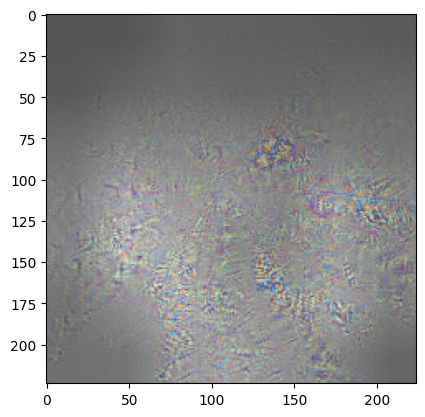

In [58]:
guided_gradcam = normalize(guided_gradcam)

plt.imshow(guided_gradcam)
plt.show()